In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, roc_auc_score)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data/diabetic_data_features.csv')
X = df.drop('readmitted', axis=1)
y = df['readmitted']

# Recreate same split as Module 5
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Load saved model
model = joblib.load('models/xgboost_model.pkl')
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.2).astype(int)

print("Everything loaded successfully!")
print(f"Test set shape: {X_test.shape}")

Everything loaded successfully!
Test set shape: (14303, 36)


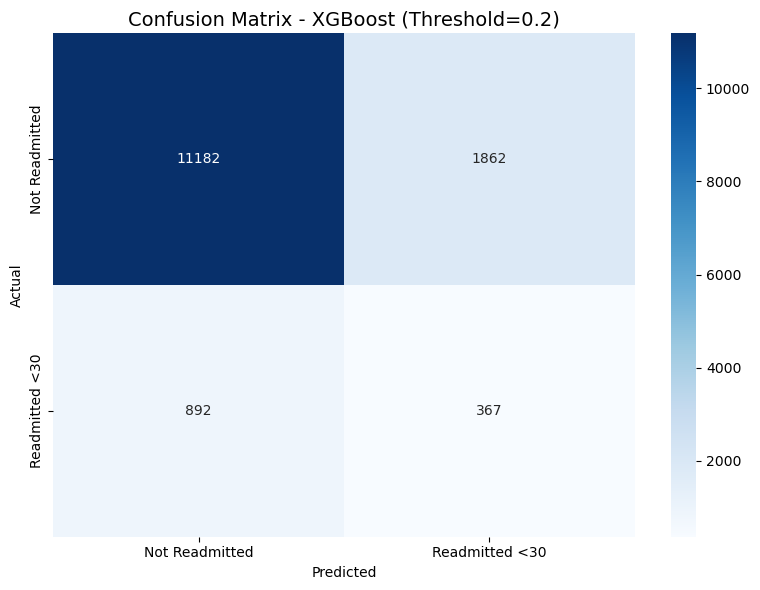

True Negatives  (Correctly predicted NOT readmitted): 11182
False Positives (Incorrectly flagged as readmitted):  1862
False Negatives (Missed actual readmissions):         892
True Positives  (Correctly caught readmissions):      367

Readmissions correctly caught: 367/14303 (29.2%)


In [2]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted <30'],
            yticklabels=['Not Readmitted', 'Readmitted <30'])

ax.set_title('Confusion Matrix - XGBoost (Threshold=0.2)', fontsize=14)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Correctly predicted NOT readmitted): {tn}")
print(f"False Positives (Incorrectly flagged as readmitted):  {fp}")
print(f"False Negatives (Missed actual readmissions):         {fn}")
print(f"True Positives  (Correctly caught readmissions):      {tp}")
print(f"\nReadmissions correctly caught: {tp}/{tn+fp+fn+tp} ({tp/(fn+tp)*100:.1f}%)")

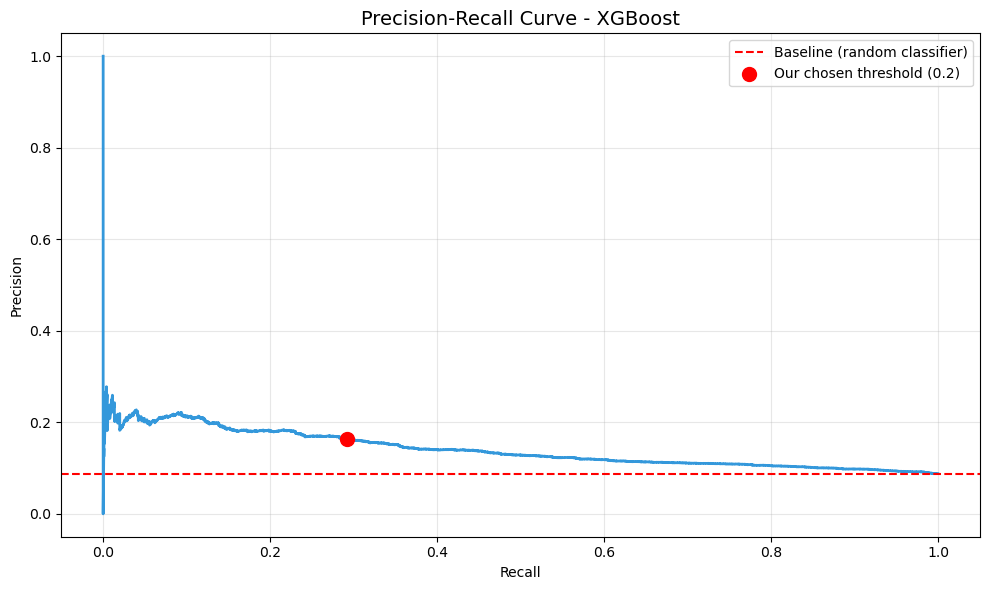

Plot saved!


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ax.plot(recall, precision, color='#3498db', linewidth=2)
ax.axhline(y=0.0880, color='red', linestyle='--', 
           label='Baseline (random classifier)')
ax.scatter([0.2915], [0.1646], color='red', s=100, zorder=5,
           label='Our chosen threshold (0.2)')

ax.set_title('Precision-Recall Curve - XGBoost', fontsize=14)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [4]:
# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on test set (use sample for speed)
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully!")
print(f"SHAP values shape: {shap_values.shape}")

SHAP values calculated successfully!
SHAP values shape: (1000, 36)


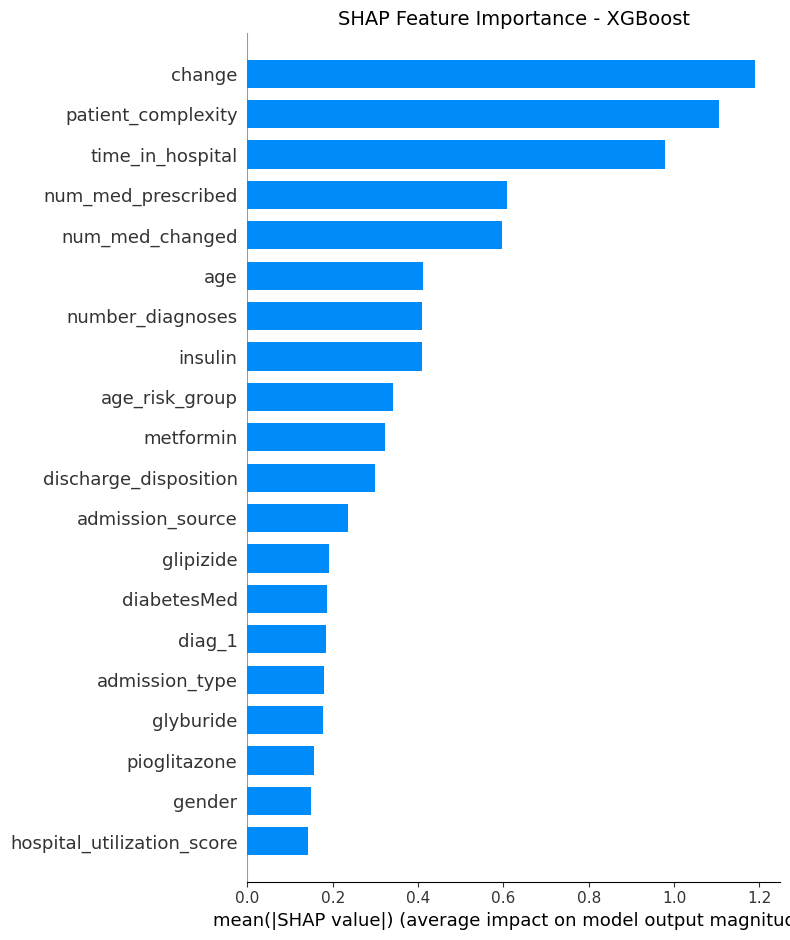

Plot saved!


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(shap_values, X_test_sample, 
                  plot_type='bar',
                  show=False)

plt.title('SHAP Feature Importance - XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('plots/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

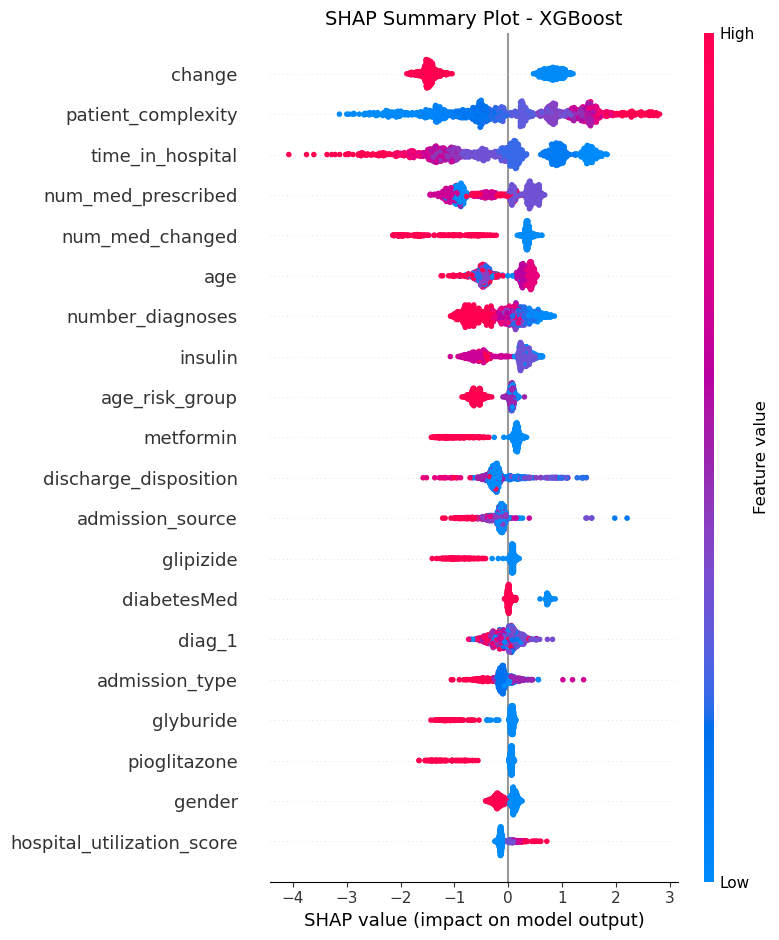

Plot saved!


In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(shap_values, X_test_sample,
                  show=False)

plt.title('SHAP Summary Plot - XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [7]:
# Explain prediction for a single high risk patient
# Find a patient who was actually readmitted
high_risk_idx = X_test[y_test == 1].index[0]
high_risk_patient = X_test.loc[[high_risk_idx]]

# Get SHAP values for this patient
shap_single = explainer.shap_values(high_risk_patient)

print("High Risk Patient Features:")
print(high_risk_patient.T)
print(f"\nActual label: {y_test.loc[high_risk_idx]}")
print(f"Predicted probability: {model.predict_proba(high_risk_patient)[0][1]:.4f}")

High Risk Patient Features:
                            60253
race                            2
gender                          1
age                            65
admission_type                  1
discharge_disposition           8
admission_source                2
time_in_hospital                4
medical_specialty               8
num_lab_procedures             56
num_procedures                  2
num_medications                20
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                        560
number_diagnoses                9
metformin                       1
repaglinide                     1
nateglinide                     1
glimepiride                     2
glipizide                       1
glyburide                       1
pioglitazone                    1
rosiglitazone                   1
acarbose                        0
miglitol                        1
insulin                         2
change              

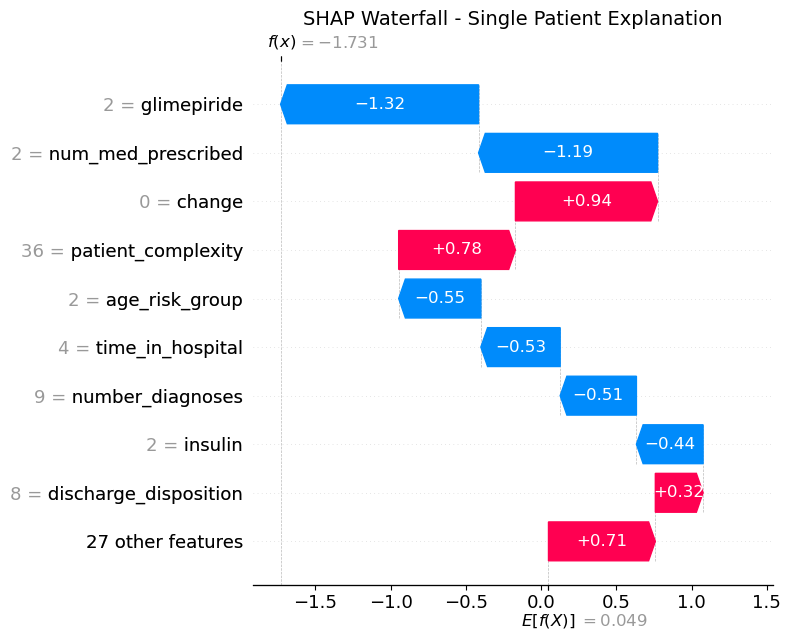

Plot saved!


In [8]:
# Waterfall plot for single patient explanation
shap_explanation = shap.Explanation(
    values=shap_single[0],
    base_values=explainer.expected_value,
    data=high_risk_patient.iloc[0],
    feature_names=X_test.columns.tolist()
)

fig, ax = plt.subplots(figsize=(12, 8))
shap.waterfall_plot(shap_explanation, show=False)
plt.title('SHAP Waterfall - Single Patient Explanation', fontsize=14)
plt.tight_layout()
plt.savefig('plots/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [9]:
print("=" * 55)
print("MODULE 6 - EVALUATION & EXPLAINABILITY SUMMARY")
print("=" * 55)
print("""
Evaluation Metrics:
-----------------------------------------------------
ROC-AUC Score      : 0.6254
Recall (Readmitted): 29.2%
Precision          : 16.4%
F1 Score           : 0.21
True Positives     : 367 readmissions caught

SHAP Top Features:
-----------------------------------------------------
1. change           - Medication changes are #1 driver
2. patient_complexity - Our engineered feature at #2!
3. time_in_hospital - Longer stays = higher risk
4. num_med_prescribed - Our engineered feature at #4!
5. num_med_changed  - Our engineered feature at #5!

Key Takeaway:
-----------------------------------------------------
✅ Model is explainable at both global and patient level
✅ 3 of top 5 features were engineered by us
✅ Clinicians can understand WHY each prediction is made
-----------------------------------------------------
Ready for Module 7 - Pipeline Automation!
""")

MODULE 6 - EVALUATION & EXPLAINABILITY SUMMARY

Evaluation Metrics:
-----------------------------------------------------
ROC-AUC Score      : 0.6254
Recall (Readmitted): 29.2%
Precision          : 16.4%
F1 Score           : 0.21
True Positives     : 367 readmissions caught

SHAP Top Features:
-----------------------------------------------------
1. change           - Medication changes are #1 driver
2. patient_complexity - Our engineered feature at #2!
3. time_in_hospital - Longer stays = higher risk
4. num_med_prescribed - Our engineered feature at #4!
5. num_med_changed  - Our engineered feature at #5!

Key Takeaway:
-----------------------------------------------------
✅ Model is explainable at both global and patient level
✅ 3 of top 5 features were engineered by us
✅ Clinicians can understand WHY each prediction is made
-----------------------------------------------------
Ready for Module 7 - Pipeline Automation!

